# TicketSim: Exploratory Data Analysis & SLA Breach Analysis

**Objective**: Audit municipal 8888 ticketing system operations, establish operational baselines, detect temporal typhoon shocks, quantify department SLA breach risks, and analyze hyper-reporter citizen distributions.

## Ticket 1: Data Ingestion, Date Preprocessing & Schema Profiling

### What we are doing in this step:
1. **Environment Setup**: Import `pandas` for data manipulation, and `matplotlib.pyplot` / `seaborn` for data visualization. Set the visual theme to `"whitegrid"` for clean readability.
2. **Data Loading**: Load the 3 exported CSV datasets (`departments.csv`, `citizens.csv`, `tickets.csv`) from the `../data/` directory.
3. **Datetime Parsing**: Convert `created_at` from a raw string into a Python `datetime` object and extract a `date` column formatted as `YYYY-MM-DD`.
4. **Relational Join (Merge)**: Perform a relational join (`df.merge()`) combining `tickets.csv` with `departments.csv` using the shared key `department_id` (like an **Excel VLOOKUP / XLOOKUP**).
5. **Data Profiling**: Inspect memory usage, column data types (`df.info()`), and preview the top 5 rows (`df.head()`).

In [1]:
# Ticket 1: Data Ingestion & Profiling

# 1. IMPORT LIBRARIES & CONFIGURE VISUALIZATION STYLE
import pandas as pd                      # Data manipulation library (Excel for Python)
import matplotlib.pyplot as plt          # Core charting & plotting engine
import seaborn as sns                    # High-level statistical visualization library

# Set Seaborn visual style to white grid for clean charts
sns.set_theme(style="whitegrid")

# 2. LOAD THE THREE CSV DATASETS FROM ../data/
df_departments = pd.read_csv("../data/departments.csv")
df_citizens = pd.read_csv("../data/citizens.csv")
df_tickets = pd.read_csv("../data/tickets.csv")

# 3. DATETIME PARSING & DATE COLUMN EXTRACTION
# Convert created_at string to datetime objects so pandas understands dates
df_tickets["created_at"] = pd.to_datetime(df_tickets["created_at"])
# Extract clean YYYY-MM-DD date string column for daily grouping
df_tickets["date"] = df_tickets["created_at"].dt.strftime("%Y-%m-%d")

# 4. RELATIONAL MERGE (VLOOKUP/XLOOKUP)
# Merge tickets with departments on department_id to attach department name and daily_capacity
df_merged = df_tickets.merge(df_departments, on="department_id", how="left")

# 5. DATA PROFILING & PREVIEW
print("=== MERGED TICKETS DATAFRAME INFO ===")
df_merged.info()

print("\n=== MERGED TICKETS HEAD (FIRST 5 ROWS) ===")
print(df_merged.head())


=== MERGED TICKETS DATAFRAME INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3199 entries, 0 to 3198
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ticket_id               3199 non-null   object        
 1   created_at              3199 non-null   datetime64[ns]
 2   department_id           3199 non-null   object        
 3   citizen_id              3199 non-null   object        
 4   resolution_time_hours   3199 non-null   float64       
 5   date                    3199 non-null   object        
 6   name                    3199 non-null   object        
 7   daily_capacity          3199 non-null   int64         
 8   vulnerability_to_storm  3199 non-null   float64       
 9   base_rate               3199 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 250.0+ KB

=== MERGED TICKETS HEAD (FIRST 5 ROWS) ===
        

## Ticket 2: The Baseline (Descriptive Analytics)

### 1. Data Hygiene Audit
Check `df_merged.isnull().sum()` to verify zero missing cells and `df_merged.duplicated().sum()` to confirm zero duplicate rows.

In [2]:
# 1. DATA HYGIENE AUDIT & NUMERICAL SUMMARY
print("=== MISSING VALUE COUNT PER COLUMN ===")
print(df_merged.isnull().sum())

print(f"\nTotal Duplicate Rows in Merged Tickets: {df_merged.duplicated().sum()}")

print("\n=== RESOLUTION TIME (HOURS) STATISTICAL SUMMARY ===")
print(df_merged["resolution_time_hours"].describe())


=== MISSING VALUE COUNT PER COLUMN ===
ticket_id                 0
created_at                0
department_id             0
citizen_id                0
resolution_time_hours     0
date                      0
name                      0
daily_capacity            0
vulnerability_to_storm    0
base_rate                 0
dtype: int64

Total Duplicate Rows in Merged Tickets: 0

=== RESOLUTION TIME (HOURS) STATISTICAL SUMMARY ===
count    3199.000000
mean        7.791779
std         7.037258
min         0.800000
25%         3.500000
50%         5.700000
75%         9.250000
max        76.100000
Name: resolution_time_hours, dtype: float64


### 2. Univariate Categorical Analysis: Department Workload Baseline
Bar chart displaying total ticket counts submitted per city department over the month.

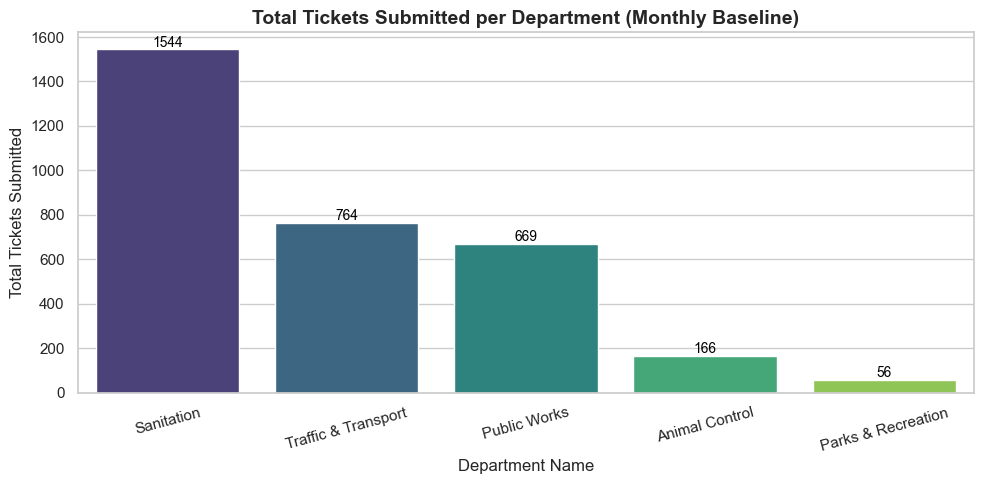

In [3]:
# CHART 1: TOTAL TICKETS PER DEPARTMENT (BAR CHART)
import matplotlib.pyplot as plt
import seaborn as sns

dept_counts = df_merged["name"].value_counts().reset_index()
dept_counts.columns = ["department_name", "total_tickets"]

plt.figure(figsize=(10, 5))
ax1 = sns.barplot(
    data=dept_counts,
    x="department_name",
    y="total_tickets",
    hue="department_name",
    palette="viridis",
    legend=False
)
plt.title("Total Tickets Submitted per Department (Monthly Baseline)", fontsize=14, fontweight="bold")
plt.xlabel("Department Name", fontsize=12)
plt.ylabel("Total Tickets Submitted", fontsize=12)
plt.xticks(rotation=15)

# Annotate exact count labels on top of bars
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height())}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha="center", va="center", 
                 fontsize=10, color="black", 
                 xytext=(0, 5), textcoords="offset points")

plt.tight_layout()
plt.show()


### 3. Univariate Numerical Analysis: Resolution Time Distribution
Histogram overlaid with a Kernel Density Estimate (KDE) curve and reference lines for median and mean resolution times.

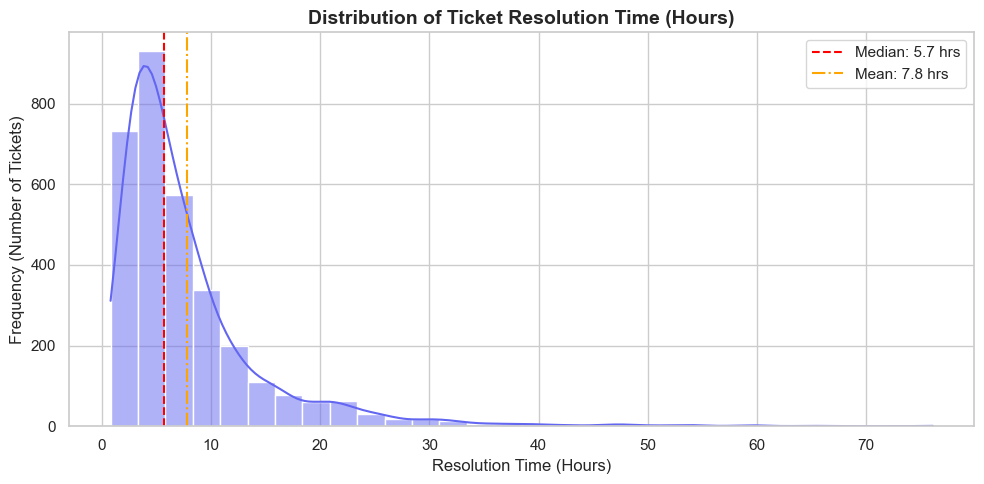

In [4]:
# CHART 2: RESOLUTION TIME DISTRIBUTION (HISTOGRAM + KDE)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(
    df_merged["resolution_time_hours"],
    kde=True,
    color="#6366f1",
    bins=30
)
plt.axvline(df_merged["resolution_time_hours"].median(), color="red", linestyle="--", label=f"Median: {df_merged['resolution_time_hours'].median():.1f} hrs")
plt.axvline(df_merged["resolution_time_hours"].mean(), color="orange", linestyle="-.", label=f"Mean: {df_merged['resolution_time_hours'].mean():.1f} hrs")

plt.title("Distribution of Ticket Resolution Time (Hours)", fontsize=14, fontweight="bold")
plt.xlabel("Resolution Time (Hours)", fontsize=12)
plt.ylabel("Frequency (Number of Tickets)", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


## Ticket 3: Temporal Anomaly Detection (Finding the Storm)

### What we are doing in this step:
1. **Daily Aggregation**: Group the 3,199 ticket rows by `date` using `df_merged.groupby("date")["ticket_id"].count()` to create a 30-day daily ticket count Time Series.
2. **Time-Series Line Plot**: Plot a line chart showing daily ticket arrivals from `2026-08-01` to `2026-08-30`.
3. **Anomaly Annotation**: Add a vertical red dashed line (`plt.axvline`) at `2026-08-15` (the day of the peak typhoon shock) and annotate the sudden volume surge from ~80 tickets/day up to **491 tickets/day**.

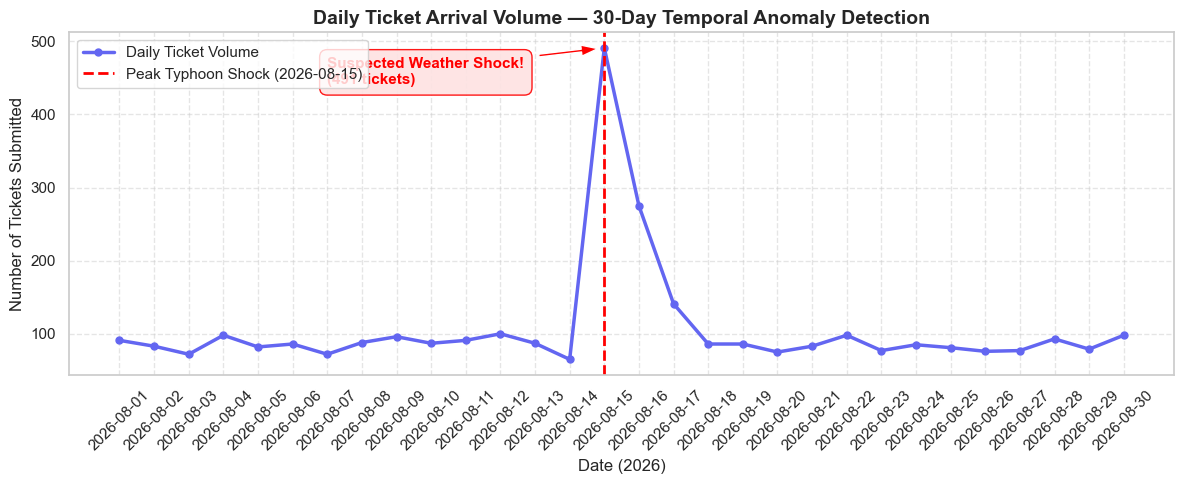

In [5]:
# Ticket 3: Temporal Anomaly Detection (Finding the Storm)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. GROUP TICKETS BY DATE TO CREATE TIME SERIES
# Group by "date" column and count ticket_id (like an Excel Pivot Table grouping dates)
daily_tickets = df_merged.groupby("date")["ticket_id"].count().reset_index()
daily_tickets.columns = ["date", "daily_ticket_count"]

# 2. TIME-SERIES LINE CHART PLOTTING
plt.figure(figsize=(12, 5))
plt.plot(
    daily_tickets["date"], 
    daily_tickets["daily_ticket_count"], 
    marker="o", 
    color="#6366f1", 
    linewidth=2.5, 
    markersize=5,
    label="Daily Ticket Volume"
)

# 3. ANOMALY HIGHLIGHTING & ANNOTATION
# Add vertical red dashed line on peak storm day (2026-08-15)
plt.axvline(x="2026-08-15", color="red", linestyle="--", linewidth=2, label="Peak Typhoon Shock (2026-08-15)")

# Annotate the peak spike with text and arrow
peak_count = daily_tickets.loc[daily_tickets["date"] == "2026-08-15", "daily_ticket_count"].values[0]
plt.annotate(
    f"Suspected Weather Shock!\n({peak_count} tickets)",
    xy=("2026-08-15", peak_count),
    xytext=("2026-08-07", peak_count - 50),
    arrowprops=dict(facecolor="red", shrink=0.08, width=2, headwidth=8),
    fontsize=11,
    fontweight="bold",
    color="red",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#fee2e2", edgecolor="red", alpha=0.9)
)

plt.title("Daily Ticket Arrival Volume — 30-Day Temporal Anomaly Detection", fontsize=14, fontweight="bold")
plt.xlabel("Date (2026)", fontsize=12)
plt.ylabel("Number of Tickets Submitted", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11, loc="upper left")
plt.tight_layout()
plt.show()
